## AIML Capstone: Sales Forecasting (Synthetic Data)

This notebook is fully self-contained:
- Creates `restaurants.csv`, `items.csv`, `sales.csv` with **exact columns** as specified in the problem statement
- Loads and merges them into one analytical dataset
- Performs the requested exploratory and business analysis
- Trains and compares **Linear Regression**, **Random Forest**, and **XGBoost** models (RMSE)
- Uses the **last 6 months** as the test set
- Forecasts the next **1 year** using the best-performing model


In [6]:
%pip install matplotlib
%pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# --- Imports and basic setup (keep this cell first) ---
import os
import math
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Where we will write the synthetic CSVs
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd()))
DATA_DIR = os.path.join(PROJECT_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

restaurants_path = os.path.join(DATA_DIR, "restaurants.csv")
items_path = os.path.join(DATA_DIR, "items.csv")
sales_path = os.path.join(DATA_DIR, "sales.csv")

PROJECT_DIR, DATA_DIR

('d:\\Study\\Simplylearn - AIML course\\Capstone\\Capstone',
 'd:\\Study\\Simplylearn - AIML course\\Capstone\\Capstone\\data')

## 1) Create the datasets (exact columns)

The problem statement mentions three datasets:
- `restaurants.csv` with columns: `id`, `name`
- `items.csv` with columns: `id`, `store_id`, `name`, `kcal`, `cost`
- `sales.csv` with columns: `date`, `item`, `Price`, `item_count`

Since the CSVs are not provided, we create realistic synthetic data with seasonality (day-of-week + month effects) and some store/item-level differences.


In [8]:
# --- Synthetic data generation (writes restaurants.csv, items.csv, sales.csv) ---

# Restaurants (stores)
store_names = [
    "Fresh Bites",
    "Urban Fork",
    "Spice Avenue",
    "Green Bowl",
    "Coastal Grill",
    "Downtown Deli",
]

restaurants = pd.DataFrame({
    "id": np.arange(1, len(store_names) + 1, dtype=int),
    "name": store_names,
})

# Items (per store)
base_items = [
    "Burger",
    "Salad",
    "Pizza",
    "Pasta",
    "Sushi",
    "Taco",
    "Soup",
    "Sandwich",
    "Coffee",
    "Juice",
]

rows = []
item_id = 1
for store_id in restaurants["id"].tolist():
    # each store sells a subset + a couple of specials
    k = rng.integers(7, 11)  # 7..10 items
    chosen = rng.choice(base_items, size=k, replace=False).tolist()
    chosen += [f"Special_{store_id}_A", f"Special_{store_id}_B"]

    for item_name in chosen:
        kcal = int(np.clip(rng.normal(420, 180), 80, 1200))

        # cost roughly increases with kcal, but noisy
        cost = float(np.clip((kcal / 120.0) + rng.normal(1.5, 0.8), 0.8, 18.0))
        cost = round(cost, 2)

        rows.append({
            "id": int(item_id),
            "store_id": int(store_id),
            "name": str(item_name),
            "kcal": int(kcal),
            "cost": float(cost),
        })
        item_id += 1

items = pd.DataFrame(rows)

# Sales: daily transactions by store-item across multiple years
start_date = pd.Timestamp("2019-01-01")
end_date = pd.Timestamp("2025-12-31")
dates = pd.date_range(start_date, end_date, freq="D")

# Create store and item effects (some stores / items sell better)
store_effect = {sid: float(np.clip(rng.normal(1.0, 0.15), 0.7, 1.4)) for sid in restaurants["id"]}
item_effect = {iid: float(np.clip(rng.normal(1.0, 0.25), 0.5, 2.0)) for iid in items["id"]}

# Simple seasonality functions
def dow_multiplier(dayofweek: int) -> float:
    # 0=Mon ... 6=Sun
    if dayofweek in (5, 6):
        return 1.25  # weekends
    if dayofweek == 4:
        return 1.10  # Friday
    return 0.95

def month_multiplier(month: int) -> float:
    # mild seasonality (holidays & summer)
    if month in (11, 12):
        return 1.15
    if month in (6, 7, 8):
        return 1.05
    if month in (1, 2):
        return 0.95
    return 1.0

sales_rows = []

# To keep runtime and file sizes reasonable, we generate sales for a random subset of items each day per store.
for dt in dates:
    dow = int(dt.dayofweek)
    mon = int(dt.month)

    day_mult = dow_multiplier(dow) * month_multiplier(mon)

    for store_id in restaurants["id"].tolist():
        store_items = items.loc[items["store_id"] == store_id].copy()

        # each day, only some items sell (simulate menu purchases)
        n_sold_items = int(rng.integers(4, min(9, len(store_items)) + 1))
        sold_today = store_items.sample(n=n_sold_items, random_state=int(rng.integers(0, 1_000_000)))

        for _, it in sold_today.iterrows():
            iid = int(it["id"])
            base = 12.0  # baseline daily demand for a selling item

            lam = base * day_mult * store_effect[store_id] * item_effect[iid]
            lam *= float(np.clip(rng.normal(1.0, 0.08), 0.75, 1.35))

            count = int(rng.poisson(lam))
            if count <= 0:
                continue

            # Price in sales.csv: derived from cost + margin, with small day noise
            margin = float(np.clip(rng.normal(1.75, 0.15), 1.3, 2.3))
            price = float(it["cost"]) * margin
            price *= float(np.clip(rng.normal(1.0, 0.02), 0.95, 1.05))
            price = round(price, 2)

            sales_rows.append({
                "date": dt.strftime("%Y-%m-%d"),
                "item": str(it["name"]),
                "Price": float(price),
                "item_count": int(count),
            })

sales = pd.DataFrame(sales_rows)

# Write to CSV (exact columns)
restaurants.to_csv(restaurants_path, index=False)
items.to_csv(items_path, index=False)
sales.to_csv(sales_path, index=False)

restaurants.head(), items.head(), sales.head(), (len(restaurants), len(items), len(sales))

(   id           name
 0   1    Fresh Bites
 1   2     Urban Fork
 2   3   Spice Avenue
 3   4     Green Bowl
 4   5  Coastal Grill,
    id  store_id      name  kcal  cost
 0   1         1    Burger   363  4.51
 1   2         1     Juice   266  4.42
 2   3         1  Sandwich   560  6.22
 3   4         1      Soup   622  7.06
 4   5         1     Pizza   265  4.00,
          date         item  Price  item_count
 0  2019-01-01  Special_1_A   7.79           8
 1  2019-01-01        Sushi   7.28          12
 2  2019-01-01     Sandwich  10.61          11
 3  2019-01-01        Pizza   7.53          10
 4  2019-01-01        Juice   7.54           7,
 (6, 60, 99559))

## 2) Preliminary analysis

- Import the datasets
- Examine shape/structure and check for outliers
- Merge into a single dataset that includes: **date, item id, price, item count, item names, kcal values, store id, store name**


In [9]:
# --- Load datasets ---
restaurants_df = pd.read_csv(restaurants_path)
items_df = pd.read_csv(items_path)
sales_df = pd.read_csv(sales_path)

print("restaurants:", restaurants_df.shape)
print("items:", items_df.shape)
print("sales:", sales_df.shape)

display(restaurants_df.head())
display(items_df.head())
display(sales_df.head())

# Basic structure
print("\nrestaurants dtypes:\n", restaurants_df.dtypes)
print("\nitems dtypes:\n", items_df.dtypes)
print("\nsales dtypes:\n", sales_df.dtypes)

# Parse date
sales_df["date"] = pd.to_datetime(sales_df["date"], errors="coerce")

# Quick sanity checks for outliers (simple IQR rule)
for col in ["Price", "item_count"]:
    q1, q3 = sales_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_rate = ((sales_df[col] < lo) | (sales_df[col] > hi)).mean()
    print(f"Outlier rate for {col}: {outlier_rate:.2%} (IQR rule)")

restaurants: (6, 2)
items: (60, 5)
sales: (99559, 4)


,id,name
0,1,Fresh Bites
1,2,Urban Fork
2,3,Spice Avenue
3,4,Green Bowl
4,5,Coastal Grill


,id,store_id,name,kcal,cost
0,1,1,Burger,363,4.51
1,2,1,Juice,266,4.42
2,3,1,Sandwich,560,6.22
3,4,1,Soup,622,7.06
4,5,1,Pizza,265,4.00


,date,item,Price,item_count
0,2019-01-01,Special_1_A,7.79,8
1,2019-01-01,Sushi,7.28,12
2,2019-01-01,Sandwich,10.61,11
3,2019-01-01,Pizza,7.53,10
4,2019-01-01,Juice,7.54,7



restaurants dtypes:
 id      int64
name      str
dtype: object

items dtypes:
 id            int64
store_id      int64
name            str
kcal          int64
cost        float64
dtype: object

sales dtypes:
 date              str
item              str
Price         float64
item_count      int64
dtype: object
Outlier rate for Price: 1.07% (IQR rule)
Outlier rate for item_count: 1.01% (IQR rule)


In [10]:
# --- Merge datasets into one analytical table ---
# sales.csv has item *name* (column: item). items.csv has (store_id, name). We'll join sales -> items on item name.
# Note: this synthetic dataset uses item names that are unique enough; in real life you'd prefer an item_id in sales.

# Prepare items lookup
items_lookup = items_df.rename(columns={
    "id": "item_id",
    "name": "item_name",
    "cost": "item_cost",
})

sales_clean = sales_df.rename(columns={
    "item": "item_name",
    "Price": "price",
}).copy()

# Join sales to items to get item_id, kcal, store_id
merged = sales_clean.merge(
    items_lookup[["item_id", "store_id", "item_name", "kcal", "item_cost"]],
    on="item_name",
    how="left",
)

# Join store info
merged = merged.merge(
    restaurants_df.rename(columns={"id": "store_id", "name": "store_name"}),
    on="store_id",
    how="left",
)

# Reorder/select the columns explicitly requested
merged = merged[[
    "date",
    "item_id",
    "price",
    "item_count",
    "item_name",
    "kcal",
    "store_id",
    "store_name",
]]

print("Merged shape:", merged.shape)
print("Missing item_id %:", merged["item_id"].isna().mean())
print("Missing store_name %:", merged["store_name"].isna().mean())

display(merged.head())

Merged shape: (411205, 8)
Missing item_id %: 0.0
Missing store_name %: 0.0


,date,item_id,price,item_count,item_name,kcal,store_id,store_name
0,2019-01-01,8,7.79,8,Special_1_A,297,1,Fresh Bites
1,2019-01-01,7,7.28,12,Sushi,411,1,Fresh Bites
2,2019-01-01,12,7.28,12,Sushi,537,2,Urban Fork
3,2019-01-01,26,7.28,12,Sushi,544,3,Spice Avenue
4,2019-01-01,34,7.28,12,Sushi,491,4,Green Bowl


## 3) Exploratory Data Analysis (EDA)

The problem statement asks to:
- Examine overall sales pattern
- Day-of-week fluctuations
- Month trends
- Quarter-wise distribution averaged over years
- Compare restaurant performance (overall + across years/months/days)


In [11]:
# --- Helpful derived fields ---
eda = merged.dropna().copy()
eda["revenue"] = eda["price"] * eda["item_count"]

eda["year"] = eda["date"].dt.year
eda["month"] = eda["date"].dt.month
eda["month_name"] = eda["date"].dt.strftime("%b")
eda["quarter"] = eda["date"].dt.quarter
eda["day_of_week"] = eda["date"].dt.dayofweek
eda["day_name"] = eda["date"].dt.strftime("%a")
eda["day"] = eda["date"].dt.day

# Overall daily totals
daily_overall = eda.groupby("date", as_index=False).agg(
    total_item_count=("item_count", "sum"),
    total_revenue=("revenue", "sum"),
)

display(daily_overall.head())
print("Date range:", daily_overall["date"].min().date(), "->", daily_overall["date"].max().date())

,date,total_item_count,total_revenue
0,2019-01-01,1642,13918.22
1,2019-01-02,1151,9751.87
2,2019-01-03,1802,15559.69
3,2019-01-04,1872,14795.41
4,2019-01-05,2383,19457.03


Date range: 2019-01-01 -> 2025-12-31


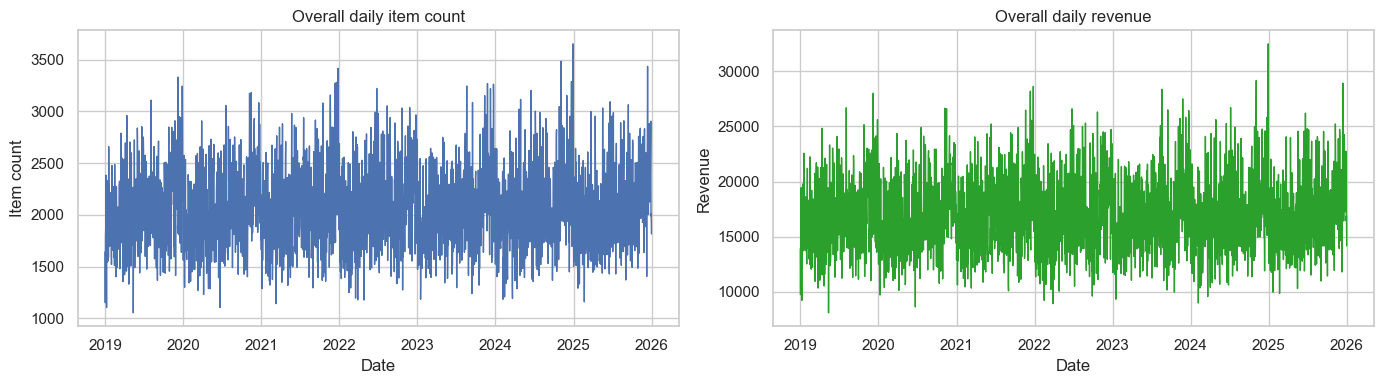

Overall totals
total_item_count     5229764.0
total_revenue       43076214.2
dtype: float64


In [12]:
# --- (a) Overall sales pattern ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(daily_overall["date"], daily_overall["total_item_count"], linewidth=1)
ax[0].set_title("Overall daily item count")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Item count")

ax[1].plot(daily_overall["date"], daily_overall["total_revenue"], linewidth=1, color="tab:green")
ax[1].set_title("Overall daily revenue")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

print("Overall totals")
print(daily_overall[["total_item_count", "total_revenue"]].sum())

,day_name,avg_item_count,avg_revenue
1,Mon,11.430205,94.261439
5,Tue,11.440666,94.204178
6,Wed,11.388218,93.543687
4,Thu,11.436681,94.163288
0,Fri,13.213754,108.863579
2,Sat,15.116499,124.592738
3,Sun,15.012137,123.756513


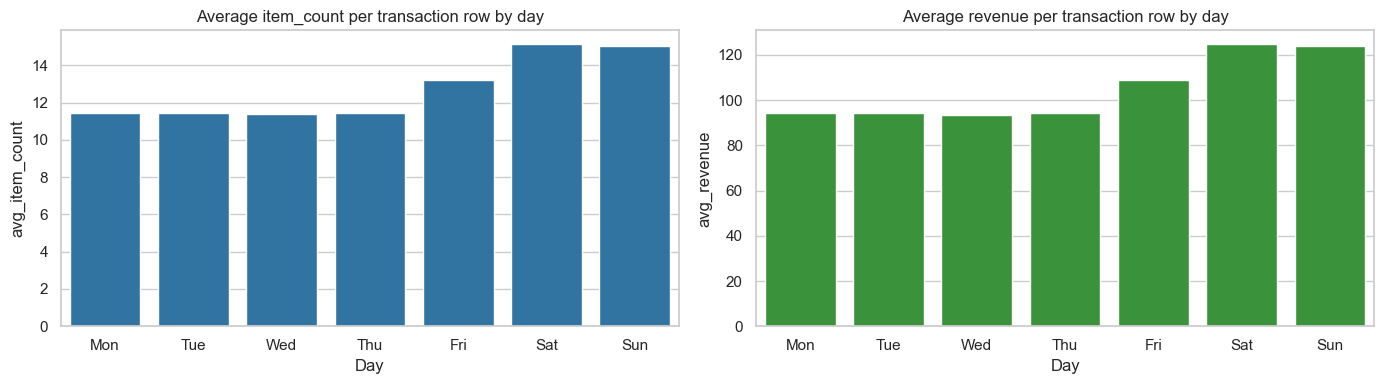

In [13]:
# --- (b) Sales by day of week ---
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = eda.groupby("day_name", as_index=False).agg(
    avg_item_count=("item_count", "mean"),
    avg_revenue=("revenue", "mean"),
)
by_dow["day_name"] = pd.Categorical(by_dow["day_name"], categories=dow_order, ordered=True)
by_dow = by_dow.sort_values("day_name")

display(by_dow)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=by_dow, x="day_name", y="avg_item_count", ax=ax[0], color="tab:blue")
ax[0].set_title("Average item_count per transaction row by day")
ax[0].set_xlabel("Day")

sns.barplot(data=by_dow, x="day_name", y="avg_revenue", ax=ax[1], color="tab:green")
ax[1].set_title("Average revenue per transaction row by day")
ax[1].set_xlabel("Day")

plt.tight_layout()
plt.show()

,month_name,avg_daily_revenue,avg_daily_items
4,Jan,95.499862,11.626741
3,Feb,97.063604,11.763599
7,Mar,102.285020,12.404996
0,Apr,101.457458,12.332768
8,May,101.227703,12.313149
6,Jun,107.126958,13.009560
5,Jul,106.766695,12.966994
1,Aug,107.753772,13.008427
11,Sep,100.789210,12.298170
10,Oct,101.920891,12.354505


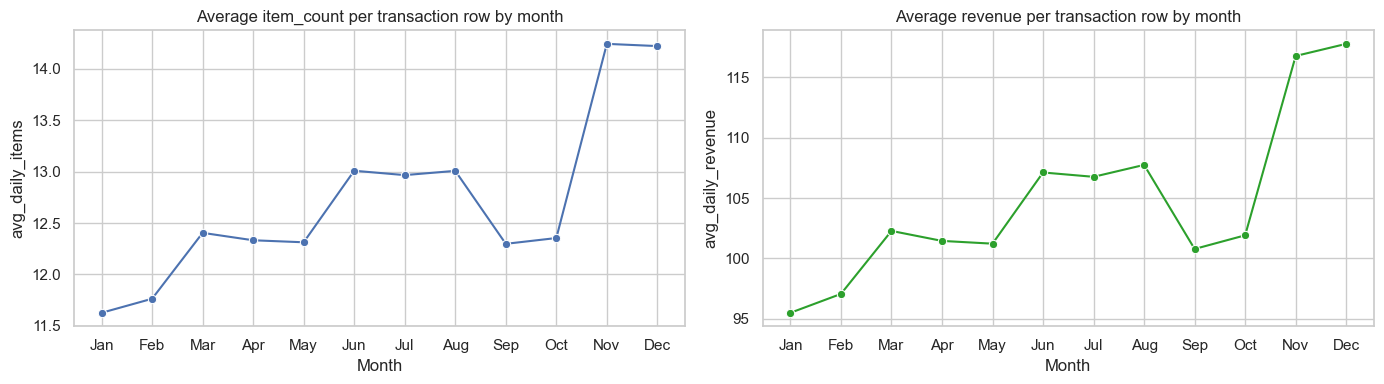

In [14]:
# --- (c) Month trends (averaged over years) ---
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
by_month = eda.groupby("month_name", as_index=False).agg(
    avg_daily_revenue=("revenue", "mean"),
    avg_daily_items=("item_count", "mean"),
)
by_month["month_name"] = pd.Categorical(by_month["month_name"], categories=month_order, ordered=True)
by_month = by_month.sort_values("month_name")

display(by_month)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=by_month, x="month_name", y="avg_daily_items", marker="o", ax=ax[0])
ax[0].set_title("Average item_count per transaction row by month")
ax[0].set_xlabel("Month")

sns.lineplot(data=by_month, x="month_name", y="avg_daily_revenue", marker="o", ax=ax[1], color="tab:green")
ax[1].set_title("Average revenue per transaction row by month")
ax[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

,quarter,avg_quarter_revenue,avg_quarter_items
0,1,1.424560e+06,172955.142857
1,2,1.502119e+06,182573.428571
2,3,1.561102e+06,189480.428571
3,4,1.665964e+06,202100.142857


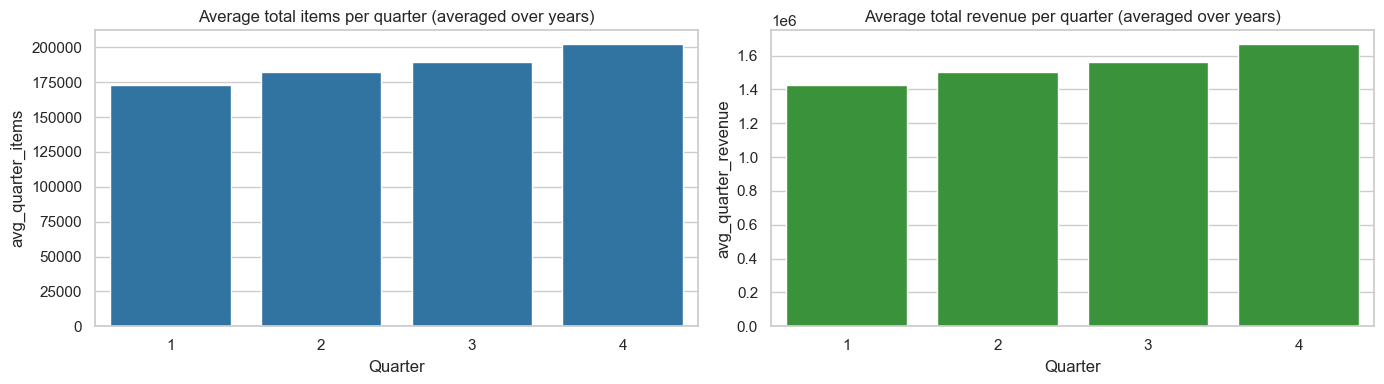

In [15]:
# --- (d) Quarter-wise distribution averaged over years ---
by_quarter = eda.groupby(["year", "quarter"], as_index=False).agg(
    total_revenue=("revenue", "sum"),
    total_items=("item_count", "sum"),
)

# Average quarter totals over years
quarter_avg = by_quarter.groupby("quarter", as_index=False).agg(
    avg_quarter_revenue=("total_revenue", "mean"),
    avg_quarter_items=("total_items", "mean"),
)

display(quarter_avg)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=quarter_avg, x="quarter", y="avg_quarter_items", ax=ax[0], color="tab:blue")
ax[0].set_title("Average total items per quarter (averaged over years)")
ax[0].set_xlabel("Quarter")

sns.barplot(data=quarter_avg, x="quarter", y="avg_quarter_revenue", ax=ax[1], color="tab:green")
ax[1].set_title("Average total revenue per quarter (averaged over years)")
ax[1].set_xlabel("Quarter")

plt.tight_layout()
plt.show()

,store_id,store_name,total_items,total_revenue
1,2,Urban Fork,1044400,8653466.30
4,5,Coastal Grill,950931,7804406.10
2,3,Spice Avenue,862790,6875209.11
3,4,Green Bowl,807921,6730302.61
5,6,Downtown Deli,785850,6551179.39
0,1,Fresh Bites,777872,6461650.69


Top store by revenue: Urban Fork


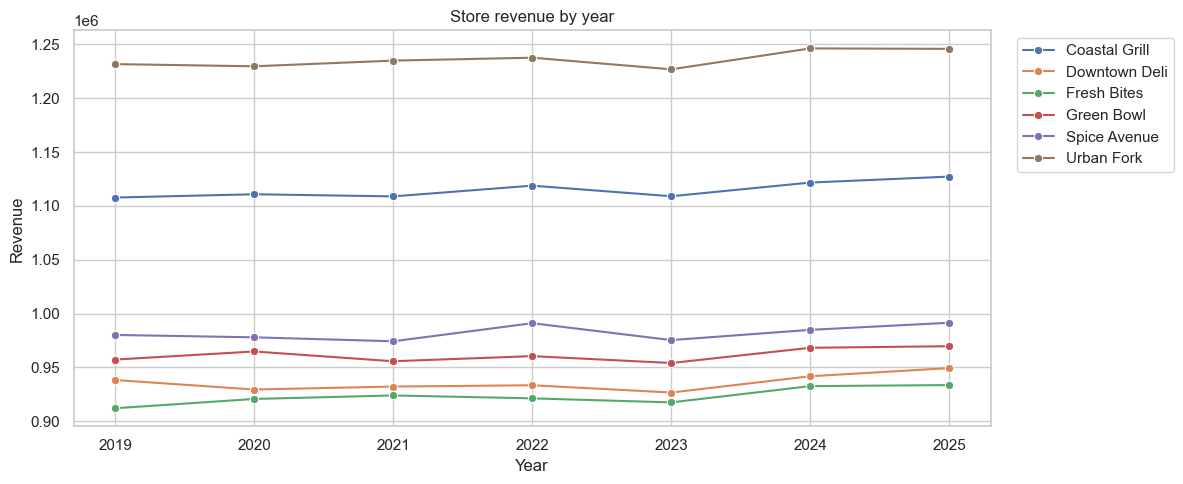

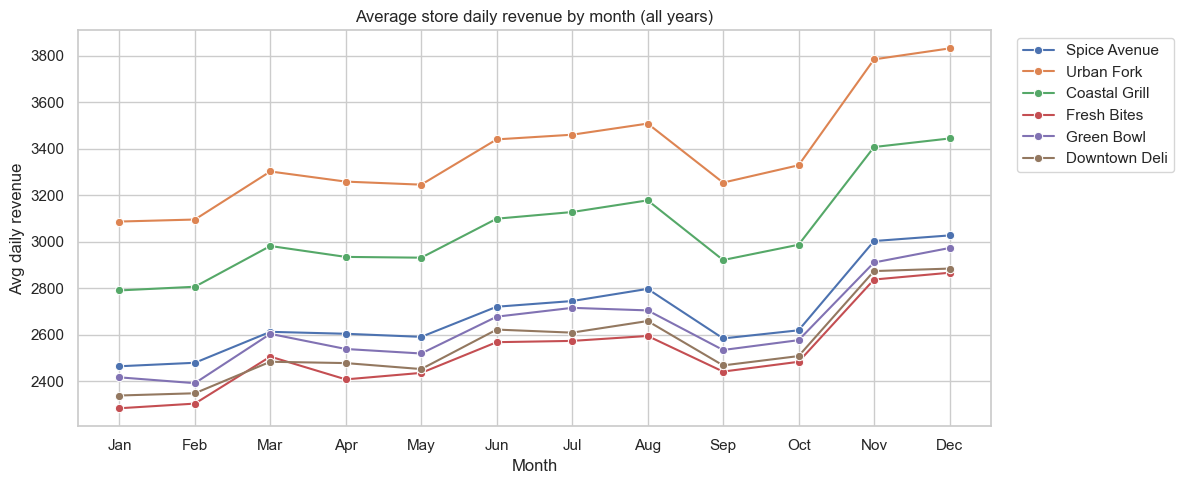

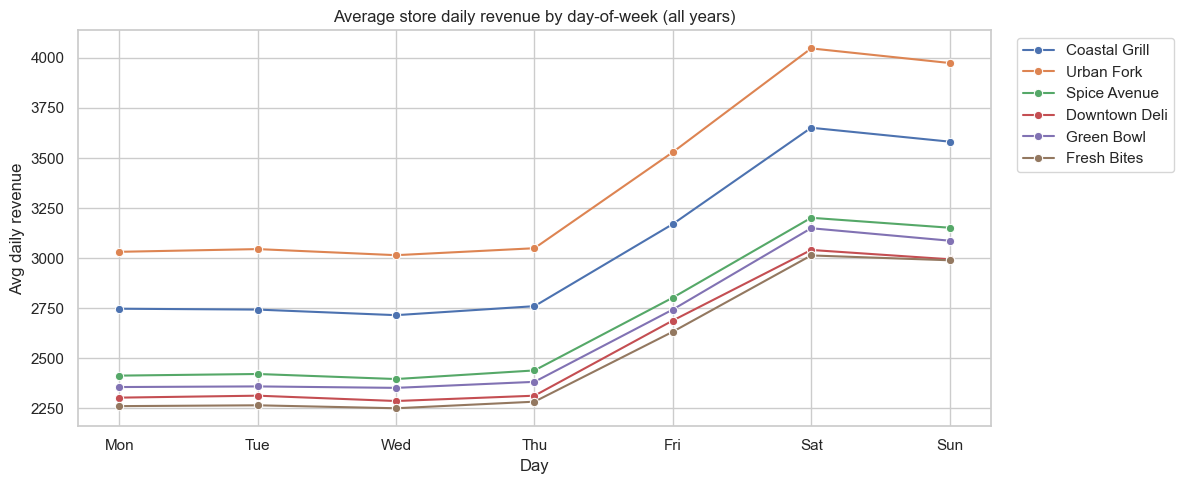

In [16]:
# --- (e) Compare restaurant performance ---
store_daily = eda.groupby(["store_id", "store_name", "date"], as_index=False).agg(
    store_daily_items=("item_count", "sum"),
    store_daily_revenue=("revenue", "sum"),
)

store_totals = store_daily.groupby(["store_id", "store_name"], as_index=False).agg(
    total_items=("store_daily_items", "sum"),
    total_revenue=("store_daily_revenue", "sum"),
)
store_totals = store_totals.sort_values("total_revenue", ascending=False)

display(store_totals)
print("Top store by revenue:", store_totals.iloc[0]["store_name"])

# Sales by year per store
store_year = store_daily.assign(year=store_daily["date"].dt.year).groupby(
    ["store_name", "year"], as_index=False
).agg(total_revenue=("store_daily_revenue", "sum"), total_items=("store_daily_items", "sum"))

plt.figure(figsize=(12, 5))
sns.lineplot(data=store_year, x="year", y="total_revenue", hue="store_name", marker="o")
plt.title("Store revenue by year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Sales by month (all years combined)
store_month = store_daily.assign(month=store_daily["date"].dt.strftime("%b")).groupby(
    ["store_name", "month"], as_index=False
).agg(avg_month_revenue=("store_daily_revenue", "mean"))
store_month["month"] = pd.Categorical(store_month["month"], categories=month_order, ordered=True)
store_month = store_month.sort_values("month")

plt.figure(figsize=(12, 5))
sns.lineplot(data=store_month, x="month", y="avg_month_revenue", hue="store_name", marker="o")
plt.title("Average store daily revenue by month (all years)")
plt.xlabel("Month")
plt.ylabel("Avg daily revenue")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Sales by day of week (all years)
store_dow = store_daily.assign(day=store_daily["date"].dt.strftime("%a")).groupby(
    ["store_name", "day"], as_index=False
).agg(avg_dow_revenue=("store_daily_revenue", "mean"))
store_dow["day"] = pd.Categorical(store_dow["day"], categories=dow_order, ordered=True)
store_dow = store_dow.sort_values("day")

plt.figure(figsize=(12, 5))
sns.lineplot(data=store_dow, x="day", y="avg_dow_revenue", hue="store_name", marker="o")
plt.title("Average store daily revenue by day-of-week (all years)")
plt.xlabel("Day")
plt.ylabel("Avg daily revenue")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4) Business questions (Data Science tasks)

The problem statement also asks to:
- Identify most popular items overall and which stores sell them; and most popular item per store
- Check whether the store with the highest sales volume also makes the most money per day
- Identify the most expensive item at each restaurant and its calorie count


In [17]:
# --- (f) Most popular items overall + stores where sold; most popular item per store ---
item_popularity = eda.groupby(["item_id", "item_name"], as_index=False).agg(
    total_sold=("item_count", "sum"),
    total_revenue=("revenue", "sum"),
)
item_popularity = item_popularity.sort_values("total_sold", ascending=False)

print("Top 10 items overall by units sold")
display(item_popularity.head(10))

# Stores where the top items are sold
top_items = item_popularity.head(5)["item_name"].tolist()
stores_selling_top = (
    eda.loc[eda["item_name"].isin(top_items), ["item_name", "store_name"]]
    .drop_duplicates()
    .sort_values(["item_name", "store_name"])
)
print("Stores selling the top 5 items")
display(stores_selling_top)

# Most popular item at each store
store_top_item = eda.groupby(["store_name", "item_name"], as_index=False).agg(total_sold=("item_count", "sum"))
store_top_item["rank"] = store_top_item.groupby("store_name")["total_sold"].rank(method="first", ascending=False)
store_top_item = store_top_item.loc[store_top_item["rank"] == 1].drop(columns=["rank"]).sort_values("total_sold", ascending=False)

print("Most popular item per store")
display(store_top_item)

Top 10 items overall by units sold


,item_id,item_name,total_sold,total_revenue
11,12,Sushi,143869,1269443.90
6,7,Sushi,143869,1269443.90
25,26,Sushi,143869,1269443.90
33,34,Sushi,143869,1269443.90
48,49,Sushi,143869,1269443.90
52,53,Sushi,143869,1269443.90
12,13,Pasta,136026,928892.43
47,48,Pasta,136026,928892.43
36,37,Pasta,136026,928892.43
22,23,Pasta,136026,928892.43


Stores selling the top 5 items


,item_name,store_name
5,Sushi,Coastal Grill
6,Sushi,Downtown Deli
1,Sushi,Fresh Bites
4,Sushi,Green Bowl
3,Sushi,Spice Avenue
2,Sushi,Urban Fork


Most popular item per store


,store_name,item_name,total_sold
9,Coastal Grill,Sushi,143869
18,Downtown Deli,Sushi,143869
28,Fresh Bites,Sushi,143869
36,Green Bowl,Sushi,143869
46,Spice Avenue,Sushi,143869
58,Urban Fork,Sushi,143869


Store with highest sales volume (total items):


,store_id,store_name,total_items
1,2,Urban Fork,1044400


Store with highest money per day (avg daily revenue):


,store_id,store_name,avg_daily_revenue
1,2,Urban Fork,3384.226163



Is it the same store? -> True


,store_id,store_name,total_items,avg_daily_revenue
1,2,Urban Fork,1044400,3384.226163
4,5,Coastal Grill,950931,3052.172898
2,3,Spice Avenue,862790,2688.779472
3,4,Green Bowl,807921,2632.108960
5,6,Downtown Deli,785850,2562.056860
0,1,Fresh Bites,777872,2527.043680


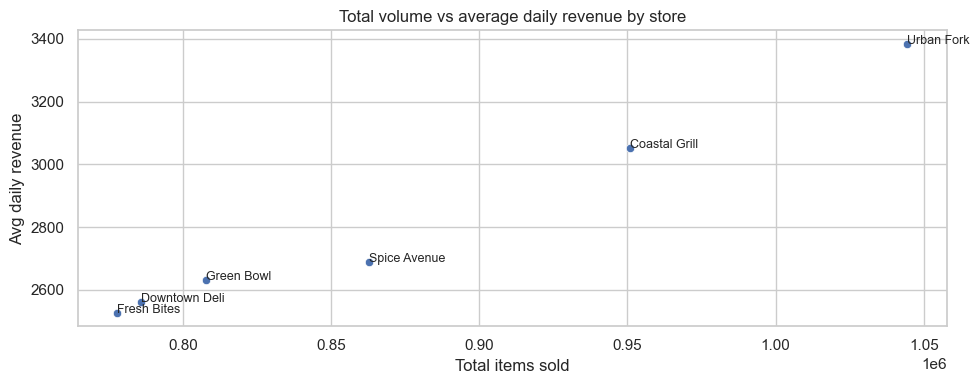

In [18]:
# --- (g) Does highest volume store also make most money per day? ---
store_day_summary = store_daily.copy()

# Identify store with highest overall volume
store_by_volume = store_day_summary.groupby(["store_id", "store_name"], as_index=False).agg(total_items=("store_daily_items", "sum"))
volume_winner = store_by_volume.sort_values("total_items", ascending=False).iloc[0]

# Identify store with highest average daily revenue
store_by_avg_money = store_day_summary.groupby(["store_id", "store_name"], as_index=False).agg(avg_daily_revenue=("store_daily_revenue", "mean"))
money_winner = store_by_avg_money.sort_values("avg_daily_revenue", ascending=False).iloc[0]

print("Store with highest sales volume (total items):")
display(volume_winner.to_frame().T)

print("Store with highest money per day (avg daily revenue):")
display(money_winner.to_frame().T)

same_store = (int(volume_winner["store_id"]) == int(money_winner["store_id"]))
print("\nIs it the same store? ->", same_store)

# Visual comparison
compare = store_by_volume.merge(store_by_avg_money, on=["store_id", "store_name"], how="inner")
compare = compare.sort_values("avg_daily_revenue", ascending=False)

display(compare)

plt.figure(figsize=(10, 4))
sns.scatterplot(data=compare, x="total_items", y="avg_daily_revenue")
for _, r in compare.iterrows():
    plt.text(r["total_items"], r["avg_daily_revenue"], r["store_name"], fontsize=9)
plt.title("Total volume vs average daily revenue by store")
plt.xlabel("Total items sold")
plt.ylabel("Avg daily revenue")
plt.tight_layout()
plt.show()

In [19]:
# --- (h) Most expensive item at each restaurant and calorie count ---
# We'll treat the max observed price for an item within a store as its most expensive sales price.

# Join store_id into sales rows by joining to items (we already have it in eda)
expensive_per_store = (
    eda.groupby(["store_id", "store_name", "item_id", "item_name"], as_index=False)
       .agg(max_price=("price", "max"), kcal=("kcal", "first"))
)

# Pick the max per store
expensive_per_store["rank"] = expensive_per_store.groupby("store_id")["max_price"].rank(method="first", ascending=False)
expensive_per_store = expensive_per_store.loc[expensive_per_store["rank"] == 1].drop(columns=["rank"])
expensive_per_store = expensive_per_store.sort_values("max_price", ascending=False)

display(expensive_per_store)

,store_id,store_name,item_id,item_name,max_price,kcal
49,5,Coastal Grill,50,Special_5_A,21.62,944
6,1,Fresh Bites,7,Sushi,17.58,411
11,2,Urban Fork,12,Sushi,17.58,537
25,3,Spice Avenue,26,Sushi,17.58,544
33,4,Green Bowl,34,Sushi,17.58,491
52,6,Downtown Deli,53,Sushi,17.58,118


## 5) Forecasting using Machine Learning

We will:
- Generate date-based features: day-of-week, quarter, month, year, day-of-month, etc.
- Use the **last 6 months** as the testing data
- Train and compare:
  - Linear Regression
  - Random Forest
  - XGBoost
- Compare models using **RMSE**
- Use the best model to forecast the next **1 year**

To keep modeling simple and aligned with the business objective, we forecast **daily store revenue** (aggregated per store per day).


In [ ]:
%pip install scikit-learn
%pip install xgboost

In [22]:
# --- Install/import ML dependencies (XGBoost) ---
# If xgboost isn't installed, this will install it in the current environment.

try:
    import xgboost  # noqa: F401
except Exception:
    import sys
    !{sys.executable} -m pip install -q xgboost

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

'd:\Study\Simplylearn' is not recognized as an internal or external command,
operable program or batch file.


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# --- Build modeling dataset (store-day level) ---
model_df = store_daily.copy()
model_df = model_df.sort_values(["store_id", "date"]).reset_index(drop=True)

# Feature engineering from date
model_df["year"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month
model_df["quarter"] = model_df["date"].dt.quarter
model_df["day_of_week"] = model_df["date"].dt.dayofweek
model_df["day_of_month"] = model_df["date"].dt.day
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)

# Optional: small amount of lag info (helps without overcomplicating)
# Using 7-day lag of store revenue
model_df["rev_lag_7"] = model_df.groupby("store_id")["store_daily_revenue"].shift(7)

# Drop early rows without lag value
model_df = model_df.dropna(subset=["rev_lag_7"]).reset_index(drop=True)

# Define target
TARGET = "store_daily_revenue"

# Train/test split: last 6 months as test
max_date = model_df["date"].max()
test_start = max_date - pd.DateOffset(months=6) + pd.Timedelta(days=1)

train_df = model_df.loc[model_df["date"] < test_start].copy()
test_df = model_df.loc[model_df["date"] >= test_start].copy()

print("Max date:", max_date.date())
print("Test start:", test_start.date())
print("Train rows:", len(train_df), "Test rows:", len(test_df))

# Features
feature_cols_num = ["year", "month", "quarter", "day_of_week", "day_of_month", "is_weekend", "rev_lag_7"]
feature_cols_cat = ["store_id"]

X_train = train_df[feature_cols_num + feature_cols_cat]
y_train = train_df[TARGET]
X_test = test_df[feature_cols_num + feature_cols_cat]
y_test = test_df[TARGET]

X_train.head()

In [ ]:
# --- Train and compare models (RMSE) ---
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ],
    remainder="drop",
)

def rmse(y_true, y_pred) -> float:
    return float(math.sqrt(mean_squared_error(y_true, y_pred)))

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    score = rmse(y_test, preds)

    results.append({"model": name, "rmse": score})
    fitted[name] = pipe

results_df = pd.DataFrame(results).sort_values("rmse")
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted[best_model_name]

print("Best model:", best_model_name)

# Plot actual vs predicted on test set (aggregated across stores per day)
plot_df = test_df[["date", "store_id", TARGET]].copy()
plot_df["pred"] = best_pipe.predict(X_test)

# aggregate to overall daily total for an easier visual
agg = plot_df.groupby("date", as_index=False).agg(actual=(TARGET, "sum"), predicted=("pred", "sum"))

plt.figure(figsize=(12, 4))
plt.plot(agg["date"], agg["actual"], label="Actual")
plt.plot(agg["date"], agg["predicted"], label="Predicted")
plt.title(f"Test period: Actual vs Predicted (overall daily revenue) - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Forecast the next year using the best model ---
# We'll build a future store-day grid and use the last available 7-day lag value.

last_date = model_df["date"].max()
future_dates = pd.date_range(last_date + timedelta(days=1), last_date + timedelta(days=365), freq="D")

# We need rev_lag_7 for future rows. We'll roll forward per store using predictions.
# This keeps the approach simple and consistent with our lag feature.

future_rows = []

for store_id in sorted(model_df["store_id"].unique()):
    hist = model_df.loc[model_df["store_id"] == store_id, ["date", TARGET]].sort_values("date").reset_index(drop=True)

    # Keep a dictionary of known/predicted revenues to reference lag-7
    known = dict(zip(hist["date"], hist[TARGET]))

    for dt in future_dates:
        # lag is revenue from 7 days earlier (from known/predicted)
        lag_dt = dt - timedelta(days=7)
        rev_lag_7 = known.get(lag_dt, np.nan)

        row = {
            "date": dt,
            "store_id": store_id,
            "year": dt.year,
            "month": dt.month,
            "quarter": ((dt.month - 1) // 3) + 1,
            "day_of_week": dt.dayofweek,
            "day_of_month": dt.day,
            "is_weekend": int(dt.dayofweek >= 5),
            "rev_lag_7": float(rev_lag_7) if pd.notna(rev_lag_7) else float(hist[TARGET].tail(7).mean()),
        }

        X_row = pd.DataFrame([row])[feature_cols_num + feature_cols_cat]
        pred = float(best_pipe.predict(X_row)[0])
        pred = max(pred, 0.0)

        known[dt] = pred
        future_rows.append({"date": dt, "store_id": store_id, "predicted_revenue": pred})

future_forecast = pd.DataFrame(future_rows)
future_forecast = future_forecast.merge(restaurants_df.rename(columns={"id": "store_id", "name": "store_name"}), on="store_id", how="left")

print("Future forecast rows:", future_forecast.shape)
display(future_forecast.head())

# Plot overall forecast
future_overall = future_forecast.groupby("date", as_index=False).agg(predicted_revenue=("predicted_revenue", "sum"))

plt.figure(figsize=(12, 4))
plt.plot(future_overall["date"], future_overall["predicted_revenue"], color="tab:purple")
plt.title(f"Next-year forecast (overall daily revenue) - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Predicted revenue")
plt.tight_layout()
plt.show()

# Show store-level total forecasted revenue
store_forecast_totals = future_forecast.groupby("store_name", as_index=False).agg(
    forecast_year_revenue=("predicted_revenue", "sum")
).sort_values("forecast_year_revenue", ascending=False)

display(store_forecast_totals)